In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN,SMOTE
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nevergrad as ng
from collections import Counter
from sklearn.impute import KNNImputer


# Load Data

In [6]:
df = pd.read_csv("./bank-additional/bank-additional/bank-additional-full.csv",delimiter=";")
df.drop(["default","emp.var.rate","previous","pdays","cons.conf.idx"], axis=1, inplace=True)
df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   housing         41188 non-null  object 
 5   loan            41188 non-null  object 
 6   contact         41188 non-null  object 
 7   month           41188 non-null  object 
 8   day_of_week     41188 non-null  object 
 9   duration        41188 non-null  int64  
 10  campaign        41188 non-null  int64  
 11  poutcome        41188 non-null  object 
 12  cons.price.idx  41188 non-null  float64
 13  euribor3m       41188 non-null  float64
 14  nr.employed     41188 non-null  float64
 15  y               41188 non-null  object 
dtypes: float64(3), int64(3), object(10)
memory usage: 5.0+ MB


# **Train - Test Split**

In [ ]:
# X & y
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Original X_train shape: {X_train.shape}")

# X_train
# X_test
# y_train
# y_test 


# Merge X_train and y_train into one DataFrame
train_df = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)

test_df = pd.concat([X_test.reset_index(drop=True),
                     y_test.reset_index(drop=True)], axis=1)


# clean test_df from error value



# Preprocessing & Feature Engineering

In [7]:
# Feature engineering and dropping columns
df['duration'] = (df['duration']/60).round()

# df.drop(['day_of_week','default','pdays'], axis=1, inplace=True)

df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:

# from sklearn.impute import KNNImputer


df = df[df['job'] != 'unknown']
df = df[df['marital'] != 'unknown']
df = df[df['education'] != 'unknown']
df = df[df['housing'] != 'unknown']
df = df[df['loan'] != 'unknown'] 
df = df[df['contact'] != 'unknown']
df = df[df['month'] != 'unknown']
df = df[df['day_of_week'] != 'unknown']




In [9]:
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,poutcome,cons.price.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,4.0,1,nonexistent,93.994,4.857,5191.0,0
1,57,services,married,high.school,no,no,telephone,may,mon,2.0,1,nonexistent,93.994,4.857,5191.0,0
2,37,services,married,high.school,yes,no,telephone,may,mon,4.0,1,nonexistent,93.994,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,3.0,1,nonexistent,93.994,4.857,5191.0,0
4,56,services,married,high.school,no,yes,telephone,may,mon,5.0,1,nonexistent,93.994,4.857,5191.0,0


In [ ]:
encoder_cols = ['education', 'job', 'month', 'poutcome','marital','housing','loan','contact','day_of_week']

# encoder_cols = ['month','loan','day_of_week']

target_encoder = TargetEncoder(cols=encoder_cols, smoothing=1.0) 

X_train_encoded = target_encoder.fit_transform(X_train, y_train)
X_test_encoded = target_encoder.transform(X_test)

print(f"Encoded X_train shape: {X_train_encoded.shape}")
X_trainNB, X_testNB, y_trainNB, y_testNB = X_train_encoded.copy(), X_test_encoded.copy(), y_train.copy(), y_test.copy()

Encoded X_train shape: (26771, 15)


# Adasync

In [ ]:
ismote = SMOTE(random_state=42, sampling_strategy = "auto", k_neighbors = 10)
X_train_res, y_train_res = ismote.fit_resample(X_train_encoded, y_train)

X_train_res_nb, y_train_res_nb = X_train_res, y_train_res # Store for Naive Bayes final fitting

X_train_res_nb_bot, y_train_res_nb_bot = X_train_res_nb.copy(), y_train_res_nb.copy()

print(f"\nResampled X_train shape: {X_train_res.shape}")
print(f"Class distribution after ADASYN: {Counter(y_train_res)}")
print(X_train_res_nb_bot.info())
print(y_train_res_nb_bot.info())


Resampled X_train shape: (47580, 15)
Class distribution after ADASYN: Counter({0: 23790, 1: 23790})
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47580 entries, 0 to 47579
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             47580 non-null  int64  
 1   job             47580 non-null  float64
 2   marital         47580 non-null  float64
 3   education       47580 non-null  float64
 4   housing         47580 non-null  float64
 5   loan            47580 non-null  float64
 6   contact         47580 non-null  float64
 7   month           47580 non-null  float64
 8   day_of_week     47580 non-null  float64
 9   duration        47580 non-null  float64
 10  campaign        47580 non-null  int64  
 11  poutcome        47580 non-null  float64
 12  cons.price.idx  47580 non-null  float64
 13  euribor3m       47580 non-null  float64
 14  nr.employed     47580 non-null  float64
dtypes: float64(13), int6

# DECISION TREE

In [16]:
# --- 6. Decision Tree Hyperparameter Tuning (using Nevergrad) ---
def evaluate_decision_tree(criterion, max_depth, min_samples_split, min_samples_leaf):
    """Evaluates a Decision Tree model using cross-validation on unresampled X_train."""

    if max_depth == -1:
        max_depth = None

    clf = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    # CV is performed on the original, encoded, but UNRESAMPLED training set
    scores = cross_val_score(clf, X_train_encoded, y_train, cv=5, scoring='accuracy') 
    return -np.mean(scores) # Nevergrad minimizes this function

param_space = ng.p.Instrumentation(
    criterion=ng.p.Choice(['gini', 'entropy', 'log_loss']),
    max_depth=ng.p.Choice([-1] + list(range(1, 21))),
    min_samples_split=ng.p.Scalar(lower=2, upper=10).set_integer_casting(),
    min_samples_leaf=ng.p.Scalar(lower=1, upper=5).set_integer_casting(),
)

optimizer = ng.optimizers.OnePlusOne(parametrization=param_space, budget=50)
best_suggestion = optimizer.minimize(
    lambda *args, **kwargs: evaluate_decision_tree(*args, **kwargs)
)

best_kwargs = best_suggestion.kwargs
best_params_dt = {
    'criterion': best_kwargs['criterion'],
    'max_depth': None if best_kwargs['max_depth'] == -1 else int(best_kwargs['max_depth']),
    'min_samples_split': int(best_kwargs['min_samples_split']),
    'min_samples_leaf': int(best_kwargs['min_samples_leaf'])
}

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

clf_best = DecisionTreeClassifier(**best_params_dt, random_state=42)
clf_best.fit(X_train_res, y_train_res)
y_pred_dt = clf_best.predict(X_test_encoded)

print("\n--- Decision Tree (Optimized) Results ---")
print(f"Best DT Params: {best_params_dt}")

# --------------------------------------------------------------------
#  TOTAL / OVERALL METRICS FOR ENTIRE DATASET
# --------------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred_dt)

precision_micro  = precision_score(y_test, y_pred_dt, average='micro', zero_division=0)
precision_macro  = precision_score(y_test, y_pred_dt, average='macro', zero_division=0)
precision_weight = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)

recall_micro  = recall_score(y_test, y_pred_dt, average='micro', zero_division=0)
recall_macro  = recall_score(y_test, y_pred_dt, average='macro', zero_division=0)
recall_weight = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)

f1_micro  = f1_score(y_test, y_pred_dt, average='micro', zero_division=0)
f1_macro  = f1_score(y_test, y_pred_dt, average='macro', zero_division=0)
f1_weight = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")

print("\n--- TOTAL METRICS (Dataset) ---")
print(f"Precision (Micro):   {precision_micro:.4f}")
print(f"Precision (Macro):   {precision_macro:.4f}")
print(f"Precision (Weighted):{precision_weight:.4f}")

print(f"Recall (Micro):      {recall_micro:.4f}")
print(f"Recall (Macro):      {recall_macro:.4f}")
print(f"Recall (Weighted):   {recall_weight:.4f}")

print(f"F1-Score (Micro):    {f1_micro:.4f}")
print(f"F1-Score (Macro):    {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weight:.4f}")

# --------------------------------------------------------------------
# Per-class metrics
# --------------------------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Feature importance
feature_importances = pd.Series(clf_best.feature_importances_, index=X_train_encoded.columns)
print("\nTop 5 Feature Importances:")
print(feature_importances.sort_values(ascending=False))



--- Decision Tree (Optimized) Results ---
Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5}
Accuracy: 0.8511

--- TOTAL METRICS (Dataset) ---
Precision (Micro):   0.8511
Precision (Macro):   0.7031
Precision (Weighted):0.9225
Recall (Micro):      0.8511
Recall (Macro):      0.8724
Recall (Weighted):   0.8511
F1-Score (Micro):    0.8511
F1-Score (Macro):    0.7416
F1-Score (Weighted): 0.8723

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     10197
           1       0.42      0.90      0.57      1277

    accuracy                           0.85     11474
   macro avg       0.70      0.87      0.74     11474
weighted avg       0.92      0.85      0.87     11474


Top 5 Feature Importances:
duration          0.529863
month             0.151461
euribor3m         0.133270
nr.employed       0.110254
poutcome          0.040914
contact           0.020606
cons.price

# Naive Bayes

In [17]:
# --- 8. Naive Bayes Hyperparameter Tuning (using Nevergrad) ---

def evaluate_nb(log10_var_smoothing):
    """Evaluates a GaussianNB model using cross-validation on unresampled X_train."""
    var_smoothing = 10.0 ** log10_var_smoothing
    clf_ = GaussianNB(var_smoothing=var_smoothing)
    # CV is performed on the original, encoded, but UNRESAMPLED training set
    scores = cross_val_score(clf_, X_trainNB, y_trainNB, cv=5, scoring='accuracy') 
    return -np.mean(scores)

param_space_nb = ng.p.Instrumentation(
    log10_var_smoothing=ng.p.Scalar(lower=-12, upper=-6)
)

optimizer_nb = ng.optimizers.OnePlusOne(parametrization=param_space_nb, budget=50)
best_suggestion_nb = optimizer_nb.minimize(lambda *a, **k: evaluate_nb(*a, **k))
best_log10_vs = float(best_suggestion_nb.kwargs['log10_var_smoothing'])
best_var_smoothing = 10.0 ** best_log10_vs

# --- 9. Final Naive Bayes Model Fitting (using Resampled Data) ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# --- 10. Final Naive Bayes Model Fitting (using Resampled Data) ---

nb_best_ = GaussianNB(var_smoothing=best_var_smoothing)
nb_best_.fit(X_train_res_nb, y_train_res_nb)
y_pred_nb = nb_best_.predict(X_testNB)

print("\n--- Naive Bayes (Optimized) Results ---")
print(f"Best NB var_smoothing: {best_var_smoothing:.2e}")

# --------------------------------------------------------------------
#  TOTAL / OVERALL METRICS FOR ENTIRE DATASET
# --------------------------------------------------------------------
accuracy_nb = accuracy_score(y_testNB, y_pred_nb)

precision_micro_nb  = precision_score(y_testNB, y_pred_nb, average='micro', zero_division=0)
precision_macro_nb  = precision_score(y_testNB, y_pred_nb, average='macro', zero_division=0)
precision_weight_nb = precision_score(y_testNB, y_pred_nb, average='weighted', zero_division=0)

recall_micro_nb  = recall_score(y_testNB, y_pred_nb, average='micro', zero_division=0)
recall_macro_nb  = recall_score(y_testNB, y_pred_nb, average='macro', zero_division=0)
recall_weight_nb = recall_score(y_testNB, y_pred_nb, average='weighted', zero_division=0)

f1_micro_nb  = f1_score(y_testNB, y_pred_nb, average='micro', zero_division=0)
f1_macro_nb  = f1_score(y_testNB, y_pred_nb, average='macro', zero_division=0)
f1_weight_nb = f1_score(y_testNB, y_pred_nb, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_nb:.4f}")

print("\n--- TOTAL METRICS (Dataset) ---")
print(f"Precision (Micro):    {precision_micro_nb:.4f}")
print(f"Precision (Macro):    {precision_macro_nb:.4f}")
print(f"Precision (Weighted): {precision_weight_nb:.4f}")

print(f"Recall (Micro):       {recall_micro_nb:.4f}")
print(f"Recall (Macro):       {recall_macro_nb:.4f}")
print(f"Recall (Weighted):    {recall_weight_nb:.4f}")

print(f"F1-Score (Micro):     {f1_micro_nb:.4f}")
print(f"F1-Score (Macro):     {f1_macro_nb:.4f}")
print(f"F1-Score (Weighted):  {f1_weight_nb:.4f}")

# --------------------------------------------------------------------
# Per-class metrics
# --------------------------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_testNB, y_pred_nb, zero_division=0))



--- Naive Bayes (Optimized) Results ---
Best NB var_smoothing: 6.33e-07
Accuracy: 0.8177

--- TOTAL METRICS (Dataset) ---
Precision (Micro):    0.8177
Precision (Macro):    0.6664
Precision (Weighted): 0.9048
Recall (Micro):       0.8177
Recall (Macro):       0.8183
Recall (Weighted):    0.8177
F1-Score (Micro):     0.8177
F1-Score (Macro):     0.6943
F1-Score (Weighted):  0.8453

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     10197
           1       0.36      0.82      0.50      1277

    accuracy                           0.82     11474
   macro avg       0.67      0.82      0.69     11474
weighted avg       0.90      0.82      0.85     11474



In [18]:
from mlxtend.evaluate import paired_ttest_kfold_cv,paired_ttest_5x2cv
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# dt = DecisionTreeClassifier(**best_params_dt, random_state=42)
# nb = GaussianNB(var_smoothing=best_var_smoothing)

t, p = paired_ttest_5x2cv(estimator1=nb_best_,
                          estimator2=clf_best,
                          X=X_train_res_nb_bot,
                          y=y_train_res_nb_bot,
                          random_seed=1)
'''
t_stat, p_value = paired_ttest_kfold_cv(
    estimator1=nb_best_,
    estimator2=clf_best,
    X=X_train_res_nb_bot,
    y=y_train_res_nb_bot,
    cv=10,
    scoring='accuracy'
)
'''
print(f"t-statistic: {t:.4f}")
print(f"p-value:     {p:.4f}")

if p < 0.05:
    print("→ Significant difference between models.")
else:
    print("→ No significant difference.")


t-statistic: -25.7758
p-value:     0.0000
→ Significant difference between models.


# OLD ORIGINAL DATA BEFORE CLF FEATURE IMPORTANCE

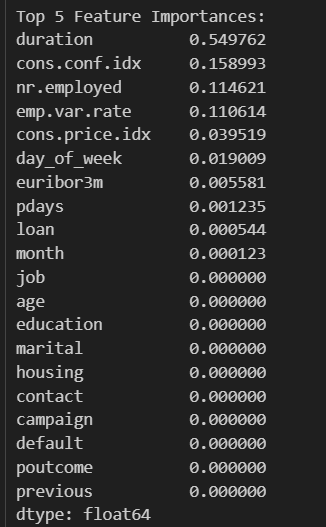

In [19]:
x = ["job","age","education","marital","housing","contact","campaign","default","poutcome","previous"]